In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset
df = pd.read_csv("heart.csv")

print(" First 5 Rows of data")
print(df.head())

print("\n Missing Values Check")
print(df.isnull().sum())

print("\n Duplicate Rows Check")
print(f"Duplicates count: {df.duplicated().sum()}")

# 2. Duplicates Remove
df = df.drop_duplicates()

# 3. Separating features (X) and Target (y)
target_col = df.columns[-1]  # automatically selecting last column
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\n Data Preprocessing Complete!")

 First 5 Rows of data
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

 Missing Values Check
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

 Duplicate Rows Check
Duplicates count: 723

 Data Preprocessing Complete!


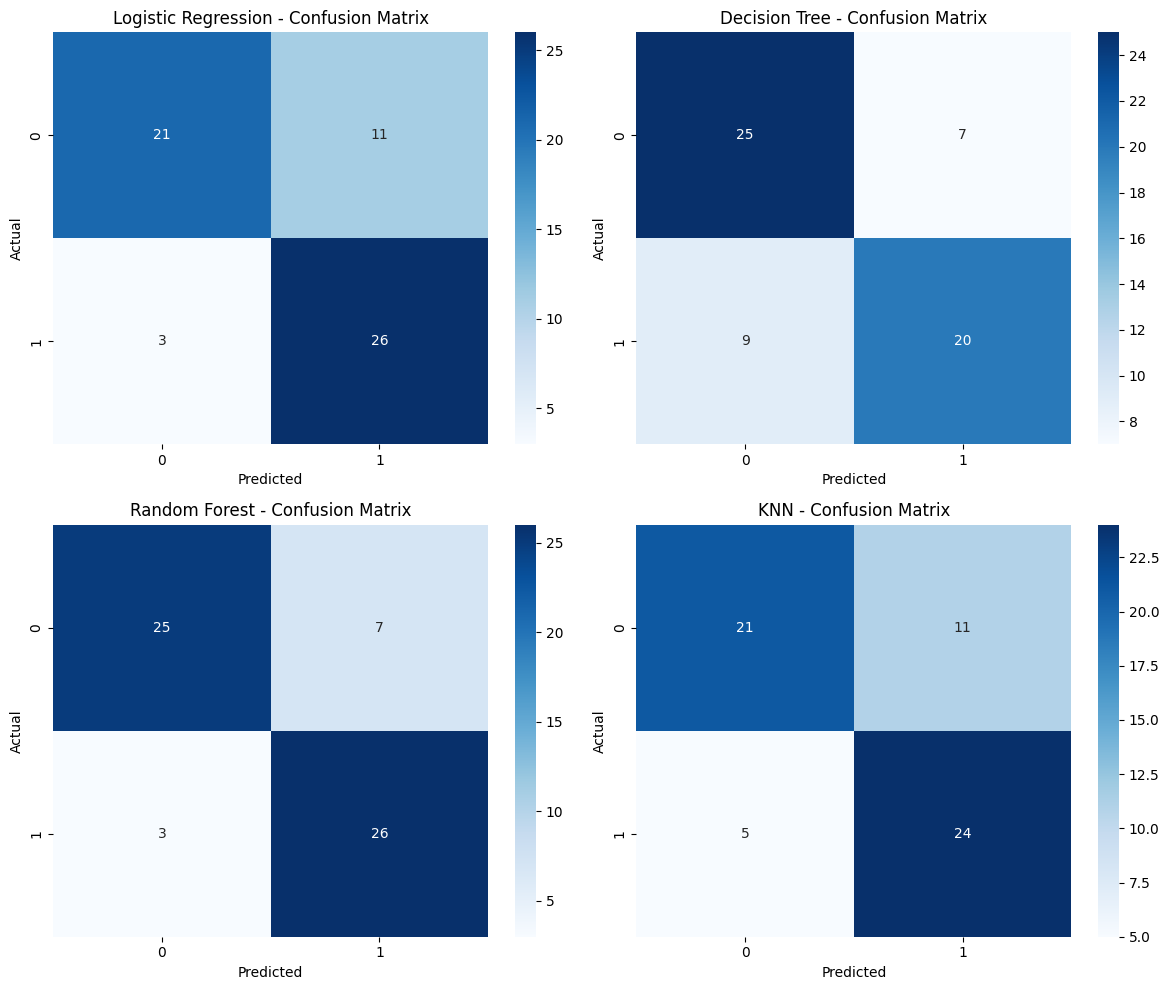

Initial Models Evaluation Results
            Model Name  Training Time (s)  Accuracy  Precision  Recall  \
0  Logistic Regression             0.0160    0.7705     0.7027  0.8966   
1        Decision Tree             0.0033    0.7377     0.7407  0.6897   
2        Random Forest             0.1136    0.8361     0.7879  0.8966   
3                  KNN             0.0023    0.7377     0.6857  0.8276   

   F1 Score  
0    0.7879  
1    0.7143  
2    0.8387  
3    0.7500  


In [3]:
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#Defining Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
}

# Results store
results = []

#  model  traininng and evaluation through loop
plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models.items(), 1):
    # Training Time Measure
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    train_time = round(end_time - start_time, 4)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics Calculation
    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred), 4)
    rec = round(recall_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)

    # Saving Results list
    results.append({
        "Model Name": name,
        "Training Time (s)": train_time,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
    })

    # Confusion Matrix Plotting
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

#Display in DataFrame
results_df = pd.DataFrame(results)
print("Initial Models Evaluation Results")
print(results_df)

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

# 1.Defining best Tuning parameters for best model
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

# 2. GridSearchCV setup
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

# 3. Model Tune
print('Tuning is starting:')
grid_search.fit(X_train, y_train)

# 4. Best Model extraction
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(f'Best Parameters: {grid_search.best_params_}')

# 5. Tuned Model Metrics
tuned_results = {
    'Model Name': 'Tuned Random Forest (Bonus)',
    'Training Time (s)': 'N/A',
    'Accuracy': round(accuracy_score(y_test, y_pred_tuned), 4),
    'Precision': round(precision_score(y_test, y_pred_tuned), 4),
    'Recall': round(recall_score(y_test, y_pred_tuned), 4),
    'F1 Score': round(f1_score(y_test, y_pred_tuned), 4),
}

# Final Table by combining results
all_results_df = pd.concat(
    [results_df, pd.DataFrame([tuned_results])], ignore_index=True
)
print('\nFINAL COMPARISON TABLE')
print(all_results_df)

Tuning is starting:
Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}

FINAL COMPARISON TABLE
                    Model Name Training Time (s)  Accuracy  Precision  Recall  \
0          Logistic Regression             0.016    0.7705     0.7027  0.8966   
1                Decision Tree            0.0033    0.7377     0.7407  0.6897   
2                Random Forest            0.1136    0.8361     0.7879  0.8966   
3                          KNN            0.0023    0.7377     0.6857  0.8276   
4  Tuned Random Forest (Bonus)               N/A    0.8197     0.7647  0.8966   

   F1 Score  
0    0.7879  
1    0.7143  
2    0.8387  
3    0.7500  
4    0.8254  
